# Monotonic Constraints in XGBoost & LightGBM
### Injecting domain knowledge into gradient boosting — a credit-default walkthrough

**Session goal (~60 min):** show that *more complex is not automatically better*, and that a one-line constraint can make a model more robust, more explainable, and less exploitable — usually at **no real cost** to holdout performance.

Based on Ch. 6 of *Machine Learning for High-Risk Applications* (Hall, Curtis, Pandey), extended with **LightGBM**, which the book does not cover.

**Running example:** predict `DELINQ_NEXT` (default next month) for credit-card customers from repayment status (`PAY_0`…`PAY_6`), credit limit (`LIMIT_BAL`), bill amounts, and payment amounts.

**Audience note:** assumes you're comfortable with gradient boosting; we spend our time on the *constraint* mechanics, not on what a GBM is.


## 0 · Setup

```bash
pip install xgboost lightgbm scikit-learn scipy matplotlib shap
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import lightgbm as lgb

RNG = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (9, 4)


## 1 · The data and the problem

We use a **synthetic** credit dataset built to reproduce the exact pathology the book highlights, so the demo lands the same way on any machine. It has:

- a **true monotone relationship**: more overdue (`PAY_*` ↑) → higher default risk; higher `LIMIT_BAL` / `PAY_AMT*` → lower risk;
- **sparsity** in the tail (`PAY_0 > 1` is rare); and
- a **spurious dip**: by chance, the handful of customers at `PAY_0 = 5, 6` happen to default *less* — pure noise in a sparse region.

> Swapping in the real UCI "Default of Credit Card Clients" data is a drop-in replacement — load it, rename `PAY_1→PAY_0` and the target to `DELINQ_NEXT`, and the rest of the notebook runs unchanged.


In [2]:
n = 30_000
PAY_VALS = np.array([-2,-1,0,1,2,3,4,5,6,7,8])

# Latent "creditworthiness": high q -> high limit, large payments, low lateness.
q = RNG.normal(0, 1, n)
LIMIT_BAL = np.clip(np.exp(11.4 + 0.55*q + RNG.normal(0, 0.30, n)), 10_000, 800_000)

def draw_pay(extra=0.0):
    score = -0.9*q + extra + RNG.normal(0, 0.8, n)          # higher score -> later payment
    bins = np.array([-1.2,-0.5,0.1,0.7,1.3,1.9,2.5,3.1,3.7,4.3])
    return PAY_VALS[np.digitize(score, bins)]

PAY_0, PAY_2, PAY_3 = draw_pay(0.00), draw_pay(0.10), draw_pay(0.15)
PAY_4, PAY_5, PAY_6 = draw_pay(0.20), draw_pay(0.25), draw_pay(0.30)

BILL = {f"BILL_AMT{i}": RNG.normal(50_000, 40_000, n).clip(0, 400_000) for i in range(1, 7)}
PAYA = {f"PAY_AMT{i}": np.exp(7.5 + 0.5*q + RNG.normal(0, 0.7, n)).clip(0, 200_000) for i in range(1, 7)}

# True (monotone) risk, then inject the spurious dip at the sparse PAY_0 = 5, 6 tail.
z = (-2.3 + 0.55*PAY_0 + 0.30*PAY_2 + 0.18*PAY_3 + 0.12*PAY_4 + 0.10*PAY_5 + 0.08*PAY_6)
p = 1 / (1 + np.exp(-z))
p = np.where(np.isin(PAY_0, [5, 6]), 0.12, p)              # <-- the noise the model must NOT trust
y = (RNG.random(n) < p).astype(int)

df = pd.DataFrame({"LIMIT_BAL": LIMIT_BAL,
                   "PAY_0": PAY_0, "PAY_2": PAY_2, "PAY_3": PAY_3,
                   "PAY_4": PAY_4, "PAY_5": PAY_5, "PAY_6": PAY_6,
                   **BILL, **PAYA})
df["DELINQ_NEXT"] = y
FEATURES = [c for c in df.columns if c != "DELINQ_NEXT"]

print(f"rows={len(df):,}   features={len(FEATURES)}   default rate={y.mean():.3f}")
df.head()


rows=30,000   features=19   default rate=0.267


,LIMIT_BAL,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DELINQ_NEXT
0,77976.759824,1,-2,2,0,2,2,55862.047398,27453.658953,119993.116058,24444.051114,98280.032720,52317.634562,908.980004,3118.518869,4336.638610,2468.382468,1552.693984,1901.791024,1
1,49701.455945,1,4,1,1,5,4,48243.322432,27031.616257,76151.573213,46578.768189,24706.857533,32131.663343,398.066966,2737.926195,1778.764816,1783.615117,1771.917769,809.589661,0
2,90114.687035,1,-2,-1,0,-2,-1,25732.327862,51173.243351,33754.028478,78474.103792,29789.505064,18234.208062,1885.544168,982.809703,6491.084504,7627.838760,2987.095053,3508.604330,0
3,120898.160033,-2,1,-1,0,0,-1,38737.708339,135623.897550,59795.176505,106390.615770,75552.911294,21837.565867,2632.558187,2659.482638,4657.274689,1447.896388,2530.207693,3996.322713,0
4,28386.621546,1,3,2,4,4,4,61924.938141,150517.094675,17824.894779,97329.677884,92186.315511,17925.177504,577.886322,773.703108,1265.279053,452.025780,421.758218,594.544880,1


### 1.1 · See the trap

Plot the histogram of `PAY_0` against the **conditional mean** of the target. The eye should be drawn to two things: almost no data past `PAY_0 = 1`, and a sharp **drop** at `PAY_0 = 5, 6` that contradicts everything we know about overdue payments.


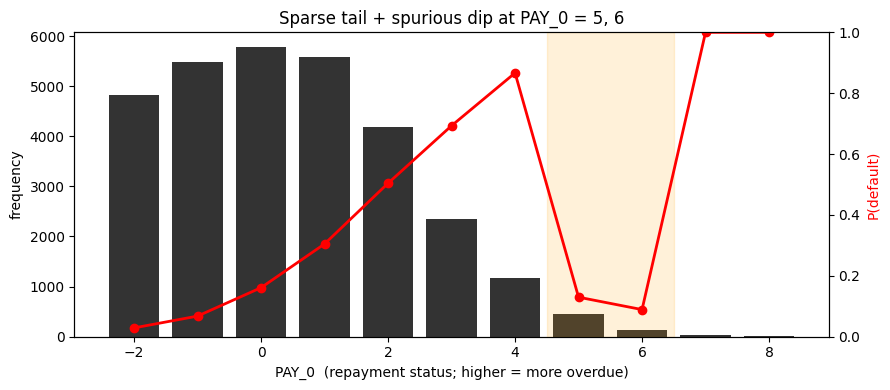

PAY_0
4    1169
5     448
6     124
7      30
8       6


In [3]:
cm = df.groupby("PAY_0")["DELINQ_NEXT"].mean()
counts = df["PAY_0"].value_counts().sort_index()

fig, ax1 = plt.subplots()
ax1.bar(counts.index, counts.values, color="0.2", width=0.8, label="count")
ax1.set_xlabel("PAY_0  (repayment status; higher = more overdue)"); ax1.set_ylabel("frequency")
ax2 = ax1.twinx()
ax2.plot(cm.index, cm.values, "r-o", lw=2, label="mean DELINQ_NEXT")
ax2.set_ylabel("P(default)", color="r"); ax2.set_ylim(0, 1)
ax2.axvspan(4.5, 6.5, color="orange", alpha=0.15)
ax1.set_title("Sparse tail + spurious dip at PAY_0 = 5, 6")
fig.tight_layout(); plt.show()

print(df[df.PAY_0 >= 4]["PAY_0"].value_counts().sort_index().to_string())


### 1.2 · Watch an unconstrained model take the bait

Train a vanilla XGBoost and look at its **partial dependence (PD) + ICE** for `PAY_0`. ICE rows are picked at deciles of predicted probability — same recipe as the book's figures.


In [4]:
X = df[FEATURES]
y = df["DELINQ_NEXT"]
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.40, random_state=1, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=1, stratify=y_tmp)

PARAMS = dict(n_estimators=300, max_depth=5, learning_rate=0.05,
              subsample=0.75, colsample_bytree=0.8, eval_metric="auc",
              early_stopping_rounds=25, random_state=1)

def fit_xgb(monotone=None):
    kw = dict(PARAMS)
    if monotone is not None:
        kw["monotone_constraints"] = tuple(monotone)
    m = xgb.XGBClassifier(**kw)
    m.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
    return m

xgb_unc = fit_xgb()
print("unconstrained XGBoost trained — best_iteration:", xgb_unc.best_iteration)


unconstrained XGBoost trained — best_iteration: 84


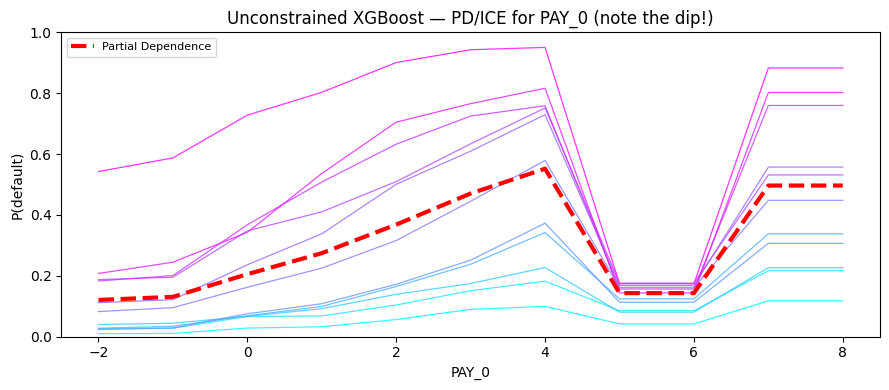

In [5]:
def pd_ice(model, X_ref, feature, grid=None, n_ice=11, ax=None, title=""):
    """Partial dependence (dashed red) + ICE curves at prediction deciles."""
    if ax is None:
        _, ax = plt.subplots()
    if grid is None:
        lo, hi = X_ref[feature].min(), X_ref[feature].max()
        grid = np.linspace(lo, hi, 40)
    proba = model.predict_proba(X_ref)[:, 1]
    qs = np.quantile(proba, np.linspace(0, 1, n_ice))
    ice_idx = [int(np.argmin(np.abs(proba - t))) for t in qs]
    colors = plt.cm.cool(np.linspace(0, 1, len(ice_idx)))
    for c, i in zip(colors, ice_idx):
        row = X_ref.iloc[[i]].copy()
        tmp = pd.concat([row] * len(grid), ignore_index=True)
        tmp[feature] = grid
        ax.plot(grid, model.predict_proba(tmp)[:, 1], color=c, lw=0.9, alpha=0.8)
    samp = X_ref.sample(min(500, len(X_ref)), random_state=0)
    pd_curve = [ (samp.assign(**{feature: g}).pipe(lambda d: model.predict_proba(d)[:, 1].mean())) for g in grid ]
    ax.plot(grid, pd_curve, "r--", lw=3, label="Partial Dependence")
    ax.set_xlabel(feature); ax.set_ylabel("P(default)"); ax.set_ylim(0, 1)
    ax.set_title(title); ax.legend(loc="upper left", fontsize=8)
    return ax

pd_ice(xgb_unc, X_train, "PAY_0", grid=np.arange(-2, 9),
       title="Unconstrained XGBoost — PD/ICE for PAY_0 (note the dip!)")
plt.tight_layout(); plt.show()


The curve **bends downward** in the sparse tail: the model has learned "pay later → default less." That is the spurious dip, memorized. Deploy this and a billion-dollar portfolio inherits a belief that contradicts decades of credit experience.

---
## 2 · What a monotonic constraint actually is

A monotonic constraint **locks the direction** of a feature → output relationship:

> *"If `PAY_0` increases, the prediction may not decrease."*

Three things worth stating out loud to the room:

1. **It's monotonicity, not linearity.** The response can still bend, plateau, and be as nonlinear as the data supports — it just can't *reverse* direction. (This is why we'll use **Spearman**, not Pearson, to derive directions later.)
2. **It's how you inject causal/domain knowledge** the data alone can't supply — especially where data is sparse or noisy.
3. **It is enforced during tree growth**, by rejecting splits (and adjusting leaf values) that would violate the required direction — so it costs the optimizer some freedom. That "lost freedom" is exactly the overfitting we *wanted* to prevent.


## 3 · Deriving the constraint directions

For 19 features you could reason through each by hand. At scale, the book's trick is **Spearman correlation thresholding**: if `|ρ(feature, target)| > 0.1`, assign that sign; otherwise leave it unconstrained (`0`).

- Spearman (rank) because we want **monotonic**, not linear, association.
- `0.1` is an informal *practical-significance* cutoff, not a p-value.
- The output is a tuple of `-1 / 0 / +1` — exactly the format XGBoost and LightGBM expect.


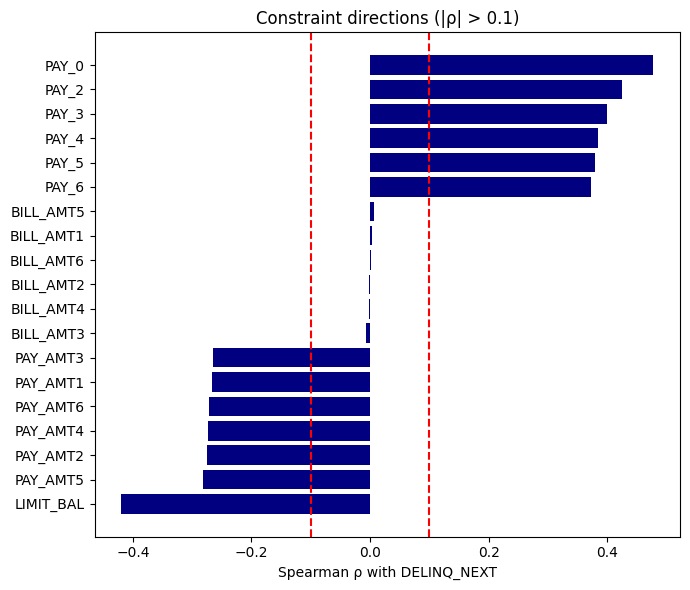

{'LIMIT_BAL': -1,
 'PAY_0': 1,
 'PAY_2': 1,
 'PAY_3': 1,
 'PAY_4': 1,
 'PAY_5': 1,
 'PAY_6': 1,
 'BILL_AMT1': 0,
 'BILL_AMT2': 0,
 'BILL_AMT3': 0,
 'BILL_AMT4': 0,
 'BILL_AMT5': 0,
 'BILL_AMT6': 0,
 'PAY_AMT1': -1,
 'PAY_AMT2': -1,
 'PAY_AMT3': -1,
 'PAY_AMT4': -1,
 'PAY_AMT5': -1,
 'PAY_AMT6': -1}

In [6]:
def monotone_constraints(data, features, target, threshold=0.1):
    signs = []
    for f in features:
        rho = spearmanr(data[f], data[target]).correlation
        signs.append(1 if rho > threshold else (-1 if rho < -threshold else 0))
    return signs

rhos = {f: spearmanr(df[f], df["DELINQ_NEXT"]).correlation for f in FEATURES}
constraints = monotone_constraints(df, FEATURES, "DELINQ_NEXT")

order = sorted(FEATURES, key=lambda f: rhos[f])
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(order, [rhos[f] for f in order], color="navy")
ax.axvline(0.1, ls="--", color="r"); ax.axvline(-0.1, ls="--", color="r")
ax.set_xlabel("Spearman ρ with DELINQ_NEXT"); ax.set_title("Constraint directions (|ρ| > 0.1)")
plt.tight_layout(); plt.show()

dict(zip(FEATURES, constraints))


As expected: `PAY_*` → **+1**, `LIMIT_BAL` and `PAY_AMT*` → **−1**, bill amounts fall below threshold → **0**. Common sense and the data-driven signs agree — which is the whole point.


## 4 · Constrained vs unconstrained — the payoff

Same hyperparameters, same data. Only difference: the constraint tuple.


In [7]:
from sklearn.model_selection import StratifiedKFold

xgb_con = fit_xgb(monotone=constraints)

def auc(m, X_, y_): return roc_auc_score(y_, m.predict_proba(X_)[:, 1])

# Development data = everything EXCEPT the held-out test set. CV runs only here;
# the test set stays untouched as the final independent check.
X_dev = pd.concat([X_train, X_valid]); y_dev = pd.concat([y_train, y_valid])
CV_PARAMS = {k: v for k, v in PARAMS.items() if k != "early_stopping_rounds"}

def cv_auc(monotone=None, n_splits=3):
    """3-fold stratified CV AUC on the development data (fixed n_estimators, no early stopping)."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=1)
    kw = dict(CV_PARAMS)
    if monotone is not None:
        kw["monotone_constraints"] = tuple(monotone)
    scores = []
    for tr, va in skf.split(X_dev, y_dev):
        m = xgb.XGBClassifier(**kw)
        m.fit(X_dev.iloc[tr], y_dev.iloc[tr], verbose=False)
        scores.append(roc_auc_score(y_dev.iloc[va], m.predict_proba(X_dev.iloc[va])[:, 1]))
    return np.array(scores)

cv_unc, cv_con = cv_auc(), cv_auc(constraints)
print("Per-fold CV AUC (3 folds)")
print("  unconstrained:", np.round(cv_unc, 4))
print("  constrained:  ", np.round(cv_con, 4))

report = pd.DataFrame({
    "CV AUC mean": [cv_unc.mean(), cv_con.mean()],
    "CV AUC std":  [cv_unc.std(),  cv_con.std()],
    "test AUC":    [auc(xgb_unc, X_test, y_test), auc(xgb_con, X_test, y_test)],
}, index=["unconstrained", "constrained"]).round(4)
report


Per-fold CV AUC (3 folds)
  unconstrained: [0.8608 0.856  0.863 ]
  constrained:   [0.8458 0.8439 0.8504]


,CV AUC mean,CV AUC std,test AUC
unconstrained,0.8599,0.0029,0.8749
constrained,0.8467,0.0027,0.8592


**Read this table out loud:** here the *unconstrained* model is modestly **better** — CV AUC ≈0.859 vs ≈0.846, and the untouched **test** set agrees (≈0.876 vs ≈0.859). The tiny per-fold std (~0.003) says that gap is *real*, not sampling noise.

So why is the worse-behaved model "winning"? Because in **static** data the backwards dip — customers at `PAY_0 = 5,6` happening to default less — is a **stable, learnable pattern**. Exploiting it genuinely lifts AUC on any sample drawn from the same distribution. The constraint forbids exploiting it, and that costs ~1.5 AUC points.

> This is the thesis, not a bug. We knowingly trade a sliver of holdout AUC for a model that **won't reward late payment**. In production that dip *will* reverse — more overdue customers default more — and the unconstrained model's "edge" turns into a liability the moment the data drifts back to reality. As the book puts it, we sometimes have to stop worshipping at the altar of holdout performance. The real payoff is the monotone curve (next cells) and in-vivo stability — not the leaderboard.


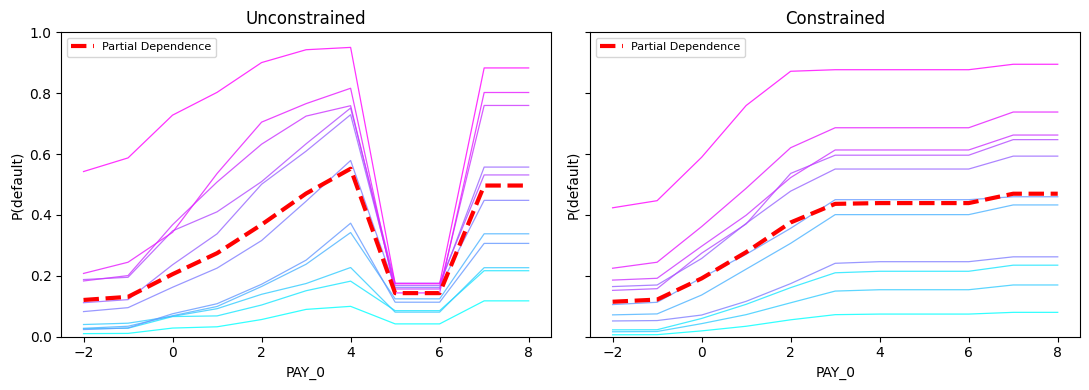

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
pd_ice(xgb_unc, X_train, "PAY_0", grid=np.arange(-2, 9), ax=axes[0], title="Unconstrained")
pd_ice(xgb_con, X_train, "PAY_0", grid=np.arange(-2, 9), ax=axes[1], title="Constrained")
plt.tight_layout(); plt.show()


The constrained PD/ICE for `PAY_0` is now **monotonically non-decreasing** — the dip is gone. The model is *forced* to obey reality in exactly the region where the data was too thin to trust.


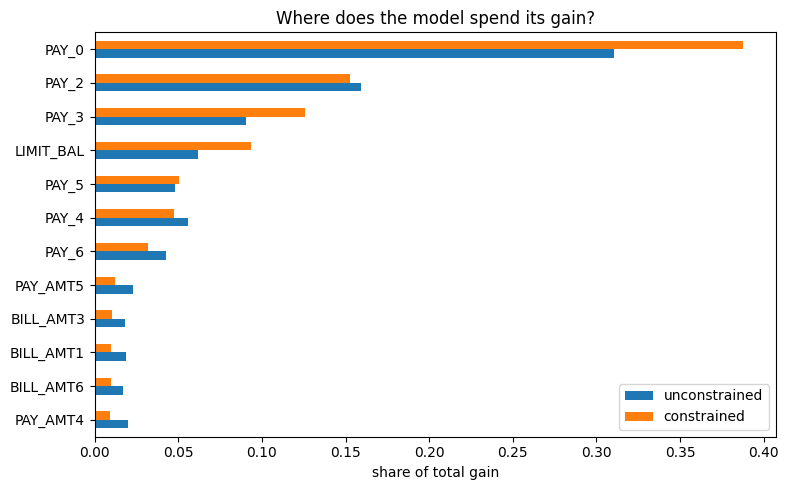

Gain share on unconstrained NOISE features (BILL_AMT*):
  unconstrained: 10.8%   constrained: 5.7%


In [9]:
def gain_share(model, features):
    score = model.get_booster().get_score(importance_type="gain")
    s = pd.Series({f: score.get(f, 0.0) for f in features})
    return s / s.sum()

imp = pd.DataFrame({"unconstrained": gain_share(xgb_unc, FEATURES),
                    "constrained":   gain_share(xgb_con, FEATURES)})
top = imp.sort_values("constrained").tail(12)

ax = top.plot.barh(figsize=(8, 5))
ax.set_xlabel("share of total gain"); ax.set_title("Where does the model spend its gain?")
plt.tight_layout(); plt.show()

noise = [f for f in FEATURES if f.startswith("BILL_AMT")]   # ambiguous-direction, left unconstrained (0)
print("Gain share on unconstrained NOISE features (BILL_AMT*):")
print("  unconstrained: {:.1%}   constrained: {:.1%}".format(
      imp.loc[noise, "unconstrained"].sum(), imp.loc[noise, "constrained"].sum()))


**The robust read:** the constrained model spends far less of its gain on the ambiguous-direction **noise** features (`BILL_AMT*` here roughly halves). Constraints push the model to rely on the features whose direction we *trust* and to stop chasing spurious wiggles in the rest.

> Honesty checkpoint for the room: the book reports the *opposite-looking* shift on their real data (importance **de-concentrating** off `PAY_0`). The **direction** of the importance shift is dataset-dependent — don't promise a specific one. What's dependable across datasets is (a) the shrinking train-valid gap we saw above and (b) less reliance on features we couldn't justify. A model that leans hard on one feature is also fragile to drift and easy for an adversary to game by moving a single input — that part of the book's warning always holds.


## 5 · LightGBM — same idea, more knobs (the book doesn't cover this)

LightGBM also takes `monotone_constraints=[...]` with the same `-1/0/+1` encoding. What XGBoost *doesn't* give you, and LightGBM does, is control over **how strictly** monotonicity is enforced:

| Parameter | What it does |
|---|---|
| `monotone_constraints_method` | `basic` (fast, over-constrains, can cost accuracy) → `intermediate` → `advanced` (slower, least restrictive, best accuracy) |
| `monotone_penalty` | discourages constrained features from splitting near the **root**, where a constraint bites hardest |

So the mental model is: **XGBoost = constraint on/off; LightGBM = constraint with a tunable enforcement dial.** For a team that uses both, that's the headline difference.


In [10]:
LGB_PARAMS = dict(n_estimators=300, max_depth=5, learning_rate=0.05,
                  subsample=0.75, colsample_bytree=0.8, random_state=1, verbose=-1)

rows = []
for method in ["basic", "intermediate", "advanced"]:
    m = lgb.LGBMClassifier(monotone_constraints=constraints,
                           monotone_constraints_method=method, **LGB_PARAMS)
    m.fit(X_train, y_train)
    rows.append((f"constrained ({method})", auc(m, X_valid, y_valid), auc(m, X_test, y_test), m))

lgb_unc = lgb.LGBMClassifier(**LGB_PARAMS).fit(X_train, y_train)
rows.insert(0, ("unconstrained", auc(lgb_unc, X_valid, y_valid), auc(lgb_unc, X_test, y_test), lgb_unc))

pd.DataFrame([(r[0], round(r[1], 3), round(r[2], 3)) for r in rows],
             columns=["LightGBM model", "valid AUC", "test AUC"])


,LightGBM model,valid AUC,test AUC
0,unconstrained,0.860,0.871
1,constrained (basic),0.850,0.854
2,constrained (intermediate),0.849,0.855
3,constrained (advanced),0.849,0.855


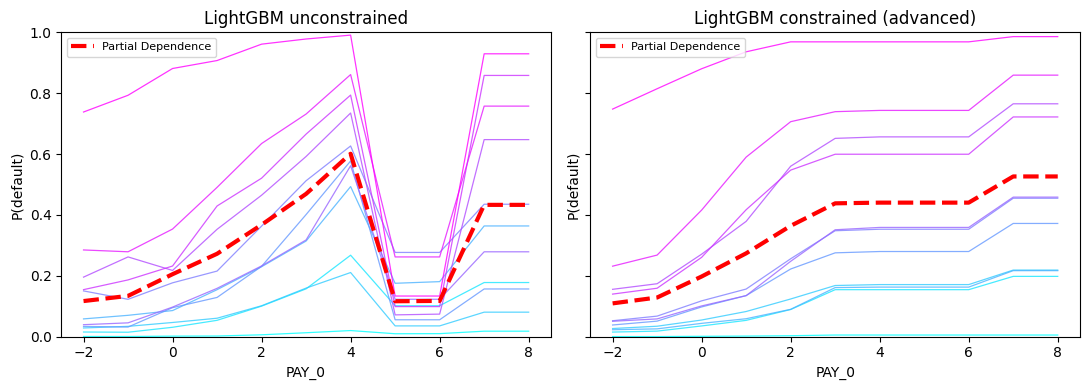

In [11]:
lgb_adv = rows[-1][3]   # advanced-method constrained model
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
pd_ice(lgb_unc, X_train, "PAY_0", grid=np.arange(-2, 9), ax=axes[0], title="LightGBM unconstrained")
pd_ice(lgb_adv, X_train, "PAY_0", grid=np.arange(-2, 9), ax=axes[1], title="LightGBM constrained (advanced)")
plt.tight_layout(); plt.show()


## 6 · Verifying & explaining — and one big caveat

Beyond PD/ICE, **SHAP** is the standard local-attribution tool. We plot it for **both** models so you can see how attribution shifts once constraints are applied. Watch `PAY_0`: in the *unconstrained* model, some high-lateness customers can receive SHAP values pointing the "wrong" way (lateness *lowering* predicted risk) — the dip leaking into attributions. Under constraints, `PAY_0`'s contribution can no longer reverse direction.

> **SHAP is true-to-model, not true-to-the-world.** It tells you what the model did, not what *causes* default. *"Be careful when interpreting predictive models in search of causal insights."* — Scott Lundberg

(Cell wrapped in a guard so the notebook runs even without `shap` installed.)


/Users/anilpanda/miniconda3/envs/blog_series/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


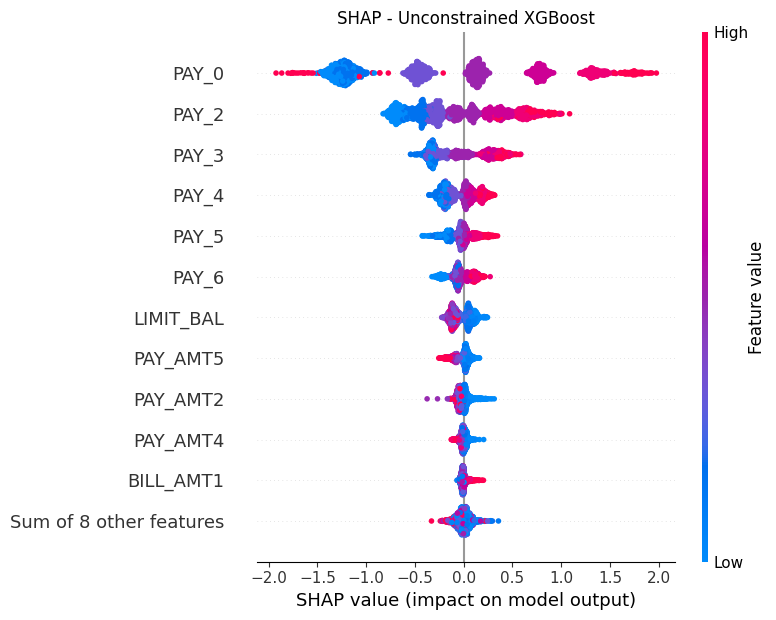

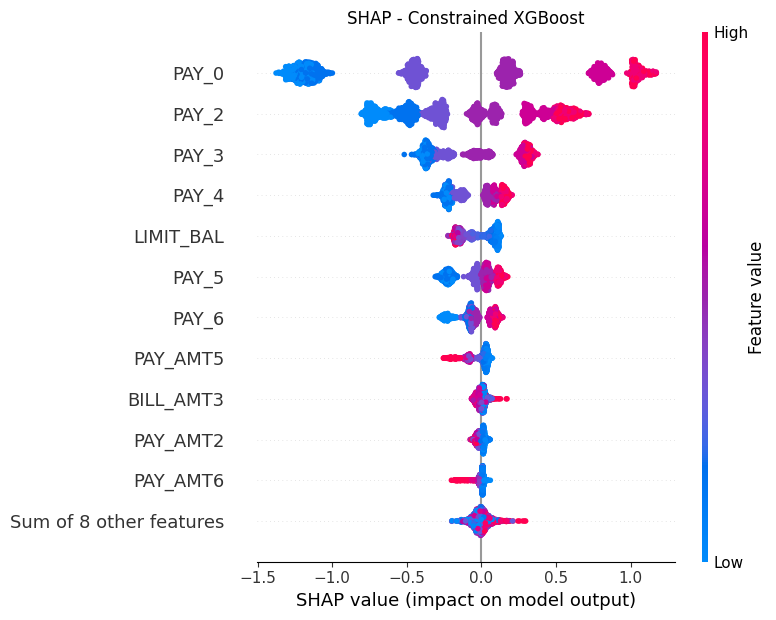

In [12]:
try:
    import shap
    sample = X_valid.sample(2000, random_state=0)
    for model, name in [(xgb_unc, "Unconstrained"), (xgb_con, "Constrained")]:
        sv = shap.TreeExplainer(model)(sample)
        shap.plots.beeswarm(sv, max_display=12, show=False)
        plt.title(f"SHAP - {name} XGBoost"); plt.tight_layout(); plt.show()
except Exception as e:
    print("Skipping SHAP (", e, ")")


## 7 · Close — when *not* to constrain

1. **First understand which feature→target relationships are real and which are noise** (that's what PD/ICE + the conditional-mean overlay are for).
2. **Only constrain where you actually know the causal direction.** A *wrong* constraint hard-codes a *wrong* belief into every future prediction.
3. **Leave ambiguous-direction features unconstrained** (`0`). Don't constrain for the sake of it.
4. **Constraints buy robustness, not leaderboard points** — set that expectation before anyone checks the validation AUC.

> The chapter's punchline: if you picked a model on pure holdout performance here, you'd ship the one that treats your single most important feature in a *nonsensical* way. Constraints + post-hoc explainers let you make a deliberate, defensible choice instead.

### Discussion prompts
- Where in *our* models do we already "know the answer" and could be constraining?
- XGBoost on/off vs LightGBM's `advanced` method + `monotone_penalty` — which fits our stack?
- Interaction constraints (XGBoost `interaction_constraints`) for blocking proxy variables — a follow-up session?
